**Installation and Imports**

In [1]:
pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 45.8 MB/s eta 0:00:00


In [2]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

**1. Define the Network Structure (DAG)**

Nodes represent factors influencing student performance.

* IQ = Intelligence level

* Study = Study time

* Attendance = Class attendance

* Sleep = Sleep quality

* Stress = Stress level

* Preparation = Overall preparation

* Exam = Exam performance

* Result = Pass or Fail

In [3]:
model = DiscreteBayesianNetwork([
    ('IQ', 'Preparation'),
    ('Study', 'Preparation'),
    ('Attendance', 'Preparation'),
    ('Sleep', 'Stress'),
    ('Preparation', 'Exam'),
    ('Stress', 'Exam'),
    ('Exam', 'Result')
])

**2. Define Conditional Probability Tables (CPDs)**

**Prior Probabilities**

In [4]:
cpd_iq = TabularCPD(
    variable='IQ',
    variable_card=2,
    values=[[0.7], [0.3]],
    state_names={'IQ': ['Low', 'High']}
)

cpd_study = TabularCPD(
    variable='Study',
    variable_card=2,
    values=[[0.6], [0.4]],
    state_names={'Study': ['Low', 'High']}
)

cpd_attendance = TabularCPD(
    variable='Attendance',
    variable_card=2,
    values=[[0.3], [0.7]],
    state_names={'Attendance': ['Low', 'High']}
)

cpd_sleep = TabularCPD(
    variable='Sleep',
    variable_card=2,
    values=[[0.4], [0.6]],
    state_names={'Sleep': ['Poor', 'Good']}
)

**Stress depends on Sleep**

In [5]:
cpd_stress = TabularCPD(
    variable='Stress',
    variable_card=2,
    values=[[0.8, 0.3],
            [0.2, 0.7]],
    evidence=['Sleep'],
    evidence_card=[2],
    state_names={
        'Stress': ['Low', 'High'],
        'Sleep': ['Poor', 'Good']
    }
)

**Preparation depends on IQ, Study, Attendance**

In [6]:
cpd_preparation = TabularCPD(
    variable='Preparation',
    variable_card=2,
    values=[
        [0.9,0.8,0.7,0.6,0.6,0.5,0.4,0.3],
        [0.1,0.2,0.3,0.4,0.4,0.5,0.6,0.7]
    ],
    evidence=['IQ','Study','Attendance'],
    evidence_card=[2,2,2],
    state_names={
        'Preparation':['Low','High'],
        'IQ':['Low','High'],
        'Study':['Low','High'],
        'Attendance':['Low','High']
    }
)

**Exam Performance depends on Preparation and Stress**

In [7]:
cpd_exam = TabularCPD(
    variable='Exam',
    variable_card=2,
    values=[
        [0.9,0.6,0.4,0.1],
        [0.1,0.4,0.6,0.9]
    ],
    evidence=['Preparation','Stress'],
    evidence_card=[2,2],
    state_names={
        'Exam':['Poor','Good'],
        'Preparation':['Low','High'],
        'Stress':['Low','High']
    }
)

**Result depends on Exam**

In [8]:
cpd_result = TabularCPD(
    variable='Result',
    variable_card=2,
    values=[
        [0.9,0.1],
        [0.1,0.9]
    ],
    evidence=['Exam'],
    evidence_card=[2],
    state_names={
        'Result':['Fail','Pass'],
        'Exam':['Poor','Good']
    }
)

**3. Add CPDs and Validate Model**

In [9]:
model.add_cpds(
    cpd_iq,
    cpd_study,
    cpd_attendance,
    cpd_sleep,
    cpd_stress,
    cpd_preparation,
    cpd_exam,
    cpd_result
)

**4. Perform Probabilistic Inference**

In [10]:
infer = VariableElimination(model)

**5. Display CPDs**

In [11]:
print("Conditional Probability Distributions:")

for cpd in model.get_cpds():
    print(cpd)

Conditional Probability Distributions:
+----------+-----+
| IQ(Low)  | 0.7 |
+----------+-----+
| IQ(High) | 0.3 |
+----------+-----+
+-------------+-----+
| Study(Low)  | 0.6 |
+-------------+-----+
| Study(High) | 0.4 |
+-------------+-----+
+------------------+-----+
| Attendance(Low)  | 0.3 |
+------------------+-----+
| Attendance(High) | 0.7 |
+------------------+-----+
+-------------+-----+
| Sleep(Poor) | 0.4 |
+-------------+-----+
| Sleep(Good) | 0.6 |
+-------------+-----+
+--------------+-------------+-------------+
| Sleep        | Sleep(Poor) | Sleep(Good) |
+--------------+-------------+-------------+
| Stress(Low)  | 0.8         | 0.3         |
+--------------+-------------+-------------+
| Stress(High) | 0.2         | 0.7         |
+--------------+-------------+-------------+
+-------------------+-----+------------------+
| IQ                | ... | IQ(High)         |
+-------------------+-----+------------------+
| Study             | ... | Study(High)      |
+-------

**Model Validation and Network Information**

In [12]:
print("Model Valid:", model.check_model())
print("Nodes:", model.nodes())
print("Edges:", model.edges())

Model Valid: True
Nodes: ['IQ', 'Preparation', 'Study', 'Attendance', 'Sleep', 'Stress', 'Exam', 'Result']
Edges: [('IQ', 'Preparation'), ('Preparation', 'Exam'), ('Study', 'Preparation'), ('Attendance', 'Preparation'), ('Sleep', 'Stress'), ('Stress', 'Exam'), ('Exam', 'Result')]


**Visualizing the Bayesian Network**

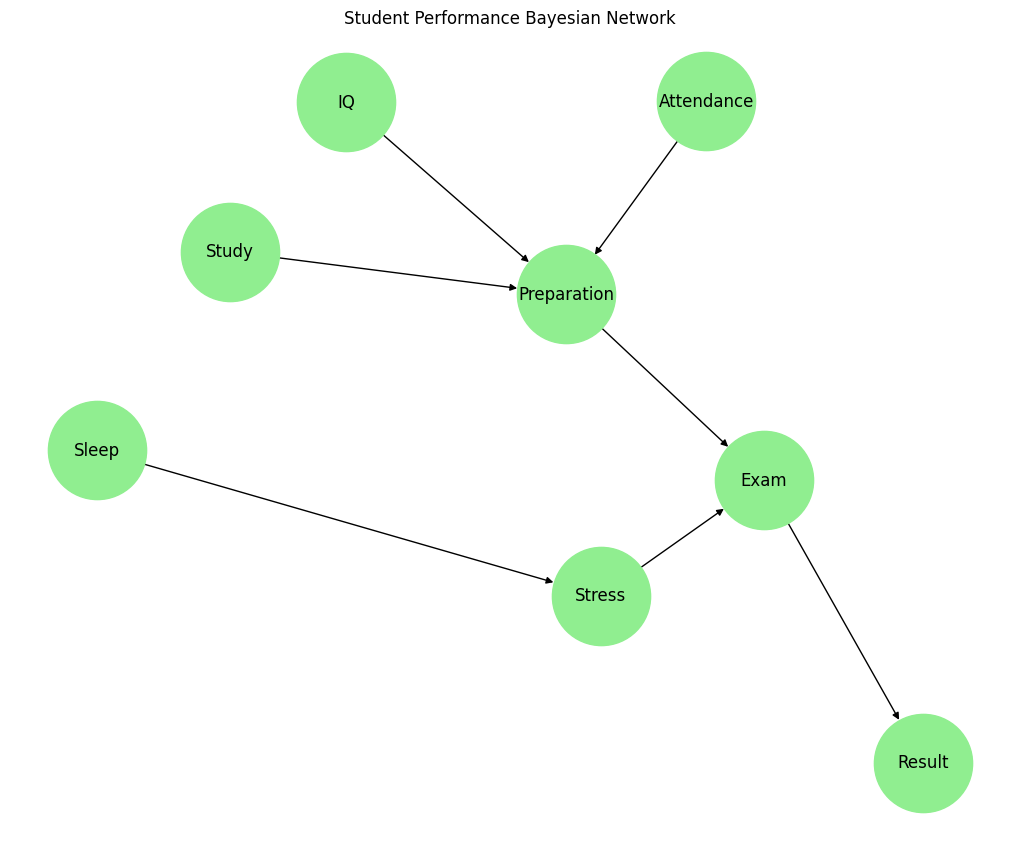

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph(model.edges())

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    node_color="lightgreen",
    font_size=12
)

plt.title("Student Performance Bayesian Network")
plt.show()

**Marginal Probability Query**

Probability that a student passes.

In [14]:
result_prob = infer.query(variables=['Result'])

print("Probability of Pass/Fail:")
print(result_prob)

Probability of Pass/Fail:
+--------------+---------------+
| Result       |   phi(Result) |
+==============+===============+
| Result(Fail) |        0.5640 |
+--------------+---------------+
| Result(Pass) |        0.4360 |
+--------------+---------------+


**Conditional Probability Query**

**Probability of Good Exam Performance if Preparation is High**

In [15]:
query1 = infer.query(
    variables=['Exam'],
    evidence={'Preparation':'High'}
)

print(query1)

+------------+-------------+
| Exam       |   phi(Exam) |
+============+=============+
| Exam(Poor) |      0.2500 |
+------------+-------------+
| Exam(Good) |      0.7500 |
+------------+-------------+


**Joint Evidence Query**

**Exam Performance when Study is High and Attendance is High**

In [16]:
query2 = infer.query(
    variables=['Exam'],
    evidence={
        'Study':'High',
        'Attendance':'High'
    }
)

print(query2)

+------------+-------------+
| Exam       |   phi(Exam) |
+============+=============+
| Exam(Poor) |      0.5050 |
+------------+-------------+
| Exam(Good) |      0.4950 |
+------------+-------------+


**Diagnostic Inference**

**If the student failed, estimate preparation level**

In [17]:
query3 = infer.query(
    variables=['Preparation'],
    evidence={'Result':'Fail'}
)

print(query3)

+-------------------+--------------------+
| Preparation       |   phi(Preparation) |
+===================+====================+
| Preparation(Low)  |             0.8191 |
+-------------------+--------------------+
| Preparation(High) |             0.1809 |
+-------------------+--------------------+


**Predictive Inference**

**Probability of passing when study is high**

In [18]:
query4 = infer.query(
    variables=['Result'],
    evidence={'Study':'High'}
)

print(query4)

+--------------+---------------+
| Result       |   phi(Result) |
+==============+===============+
| Result(Fail) |        0.5160 |
+--------------+---------------+
| Result(Pass) |        0.4840 |
+--------------+---------------+


**Scenario Analysis**

**Case: Good Sleep, High Study, High Attendance**

In [19]:
scenario = infer.query(
    variables=['Result','Exam'],
    evidence={
        'Sleep':'Good',
        'Study':'High',
        'Attendance':'High'
    }
)

print(scenario)

+--------------+------------+--------------------+
| Result       | Exam       |   phi(Result,Exam) |
+==============+============+====================+
| Result(Fail) | Exam(Poor) |             0.4005 |
+--------------+------------+--------------------+
| Result(Fail) | Exam(Good) |             0.0555 |
+--------------+------------+--------------------+
| Result(Pass) | Exam(Poor) |             0.0445 |
+--------------+------------+--------------------+
| Result(Pass) | Exam(Good) |             0.4995 |
+--------------+------------+--------------------+


**Observations**

1. High study time and attendance significantly increase preparation.

2. Good sleep quality reduces stress levels.

3. High preparation increases probability of good exam performance.

4. Exam performance directly determines the final result.

**Conclusion**

A Bayesian Network was successfully constructed using pgmpy, defining multiple variables affecting student academic performance. Conditional probability tables were created, the model was validated, and probabilistic inference was performed using various queries to analyze predictions and causal relationships within the network.